In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split



In [4]:
df = pd.read_csv("/content/data.csv")

Problem 1:
Scenario:
A data scientist writes the following code:


from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split

df = pd.read_csv('data.csv')

imputer = SimpleImputer(strategy='median')

df[['Age', 'Salary']] = imputer.fit_transform(df[['Age', 'Salary']])

X = df.drop('Target', axis=1)

y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)



#### Question: Identify the data leakage issue. Explain why it is wrong and write the corrected code.


The Issue: Data Leakage
The data leakage occurs because the SimpleImputer is fitted on the entire dataset (df[['Age', 'Salary']]) before the train-test split. The imputer calculates the median using data from both the training and test sets. By doing this, information about the test set "leaks" into the training process, which will result in overly optimistic evaluation metrics. The model should never have access to the test set's statistical properties.

Corrected Code:
You should split the data first, fit_transform on the training set, and only transform on the testing set.


In [5]:

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('data.csv')

X = df.drop('Target', axis=1)
y = df['Target']

# 1. Split the data FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize the Imputer
imputer = SimpleImputer(strategy='median')

# 3. Fit and Transform ONLY on the training data
X_train[['Age', 'Salary']] = imputer.fit_transform(X_train[['Age', 'Salary']])

# 4. Transform the testing data using the parameters learned from the train data
X_test[['Age', 'Salary']] = imputer.transform(X_test[['Age', 'Salary']])

Problem 2:

Question:
Using the provided data.csv file, write code to find:
*   Total missing values in each column
*   Percentage of missing values per column
*   Which columns have more than 50% missing values?


In [6]:
df.isnull().sum()

,0
Age,180
Income,150
Salary,0
Rating,80
Annual_Income,120
Customer_Support_Calls,80
House_Price,100
Square_Feet,0
Temperature,50
City,50


In [7]:
df.isnull().sum() / len(df) * 100

,0
Age,18.0
Income,15.0
Salary,0.0
Rating,8.0
Annual_Income,12.0
Customer_Support_Calls,8.0
House_Price,10.0
Square_Feet,0.0
Temperature,5.0
City,5.0


In [15]:
missing_pct = df.isnull().sum() / len(df) * 100
more_50 = missing_pct[missing_pct > 50]     # df[["x"]] : x = ['x'] : df[x]  .
more_50

,0
Cabin,68.0


Problem 3:

Question: Look at the Temperature column in data.csv. It contains:
*   Numeric values like 22.5, 18.6
*   String 'Unknown'
*   NaN values

Write code to handle this column properly before imputation.


In [17]:
df.head()

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,15.1,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,28.3,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,22.0,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,22.7,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51


In [22]:
df['Temperature'] = df['Temperature'].replace('Unknown', np.nan)
df['Temperature'] = pd.to_numeric(df['Temperature'])
df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,NaN,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,NaN,Chittagong,C,C,Type3,NaN,S,Female,1,314.83
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,NaN,Sylhet,A,C,Type1,NaN,C,Female,0,252.43
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,NaN,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,NaN,Dhaka,A,C,Type1,NaN,C,Female,0,309.92
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,NaN,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,NaN,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,NaN,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69


Problem 4:

Question: For the Diagnosis column in data.csv, implement imputation with:
*   Constant strategy using 'Missing' string
*   Add a missing indicator column

Write the complete code using SimpleImputer.


In [32]:
imputer = SimpleImputer(strategy='constant', fill_value="Missing", add_indicator=True)
imputer.fit(df[['Diagnosis']])
df[['Diagnosis_Imputed', "Diagnosis_Is_Missing"]] = imputer.transform(df[['Diagnosis']])
df

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,Product_Type,Location,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target,Diagnosis_Imputed,Diagnosis_Is_Missing
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,NaN,Dhaka,Unknown,A,NaN,NaN,S,Male,0,280.32,Missing,True
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,NaN,Chittagong,C,C,Type3,NaN,S,Female,1,314.83,Type3,False
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,NaN,Sylhet,A,C,Type1,NaN,C,Female,0,252.43,Type1,False
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,NaN,Rajshahi,C,B,Type2,NaN,S,Female,0,239.21,Type2,False
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,A,C,Type2,NaN,S,Female,0,179.51,Type2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,NaN,Dhaka,A,C,Type1,NaN,C,Female,0,309.92,Type1,False
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,NaN,Sylhet,A,C,Type1,Cabin_D,S,Male,0,222.41,Type1,False
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,NaN,Rajshahi,C,B,Type2,NaN,S,Female,0,221.89,Type2,False
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,NaN,Rajshahi,B,B,NaN,NaN,Q,Female,0,293.69,Missing,True


Problem 5:

Question: Using the Age column from data.csv:
*   Calculate mean and median from training data only
*   Create two new columns: Age_mean_imputed and Age_median_imputed
*   Plot KDE for both to compare distributions

Which one would you choose and why?


In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test= train_test_split(df[['Age']], test_size=0.2, random_state=42)

mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

df['Age_mean_imputed'] = df['Age'].fillna(mean_age)
df['Age_median_imputed'] = df['Age'].fillna(median_age)

,Age,Income,Salary,Rating,Annual_Income,Customer_Support_Calls,House_Price,Square_Feet,Temperature,City,...,Diagnosis,Cabin,Embarked,Gender,Target,Price_Target,Diagnosis_Imputed,Diagnosis_Is_Missing,Age_mean_imputed,Age_median_imputed
0,40.0,9165.0,55361,2.9,NaN,NaN,495310.0,2091,NaN,Dhaka,...,NaN,NaN,S,Male,0,280.32,Missing,True,40.000000,40.0
1,33.0,5522.0,48717,NaN,52868.0,1.0,368695.0,1504,NaN,Chittagong,...,Type3,NaN,S,Female,1,314.83,Type3,False,33.000000,33.0
2,42.0,50589.0,64787,3.1,79526.0,2.0,453606.0,2052,NaN,Sylhet,...,Type1,NaN,C,Female,0,252.43,Type1,False,42.000000,42.0
3,53.0,61289.0,80106,3.6,107581.0,1.0,359753.0,2075,NaN,Rajshahi,...,Type2,NaN,S,Female,0,239.21,Type2,False,53.000000,53.0
4,32.0,1604.0,31872,4.0,89654.0,1.0,228869.0,1248,NaN,Rajshahi,...,Type2,NaN,S,Female,0,179.51,Type2,False,32.000000,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,31.0,16472.0,50253,3.2,82289.0,4.0,NaN,1832,NaN,Dhaka,...,Type1,NaN,C,Female,0,309.92,Type1,False,31.000000,31.0
996,56.0,11596.0,41951,2.7,32733.0,2.0,NaN,1127,NaN,Sylhet,...,Type1,Cabin_D,S,Male,0,222.41,Type1,False,56.000000,56.0
997,42.0,NaN,44369,2.6,50537.0,2.0,346644.0,1654,NaN,Rajshahi,...,Type2,NaN,S,Female,0,221.89,Type2,False,42.000000,42.0
998,NaN,276.0,52691,3.9,143880.0,4.0,307904.0,1908,NaN,Rajshahi,...,NaN,NaN,Q,Female,0,293.69,Missing,True,34.633888,34.0


<Axes: xlabel='Age_mean_imputed', ylabel='Density'>

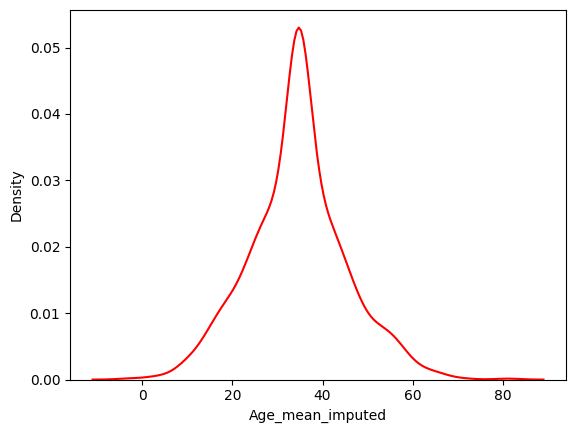

In [41]:
sns.kdeplot(df['Age_mean_imputed'], label='Mean Imputed', color='red')


<Axes: xlabel='Age_median_imputed', ylabel='Density'>

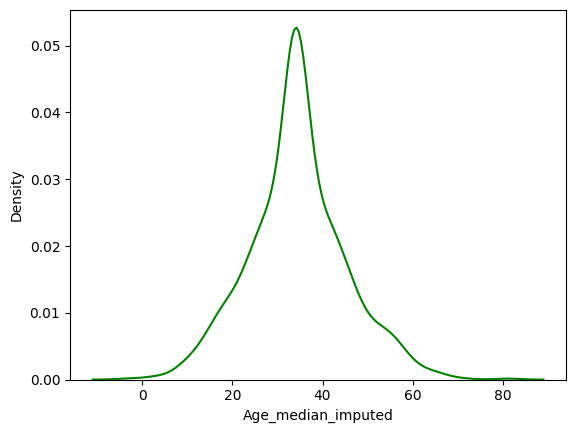

In [42]:
sns.kdeplot(df['Age_median_imputed'], label='Median Imputed', color='green')

For this specific dataset, I would choose Median Imputation.
While the original Age distribution has a very low skewness (meaning the mean 34.6 and median 34.0 are nearly identical and their curves closely overlap), the median is still the safer option. Age is generally represented as an integer, and the median yields a whole number that genuinely exists in your distribution. Furthermore, the median inherently guards against extreme outliers; if invalid extreme ages (like 150) were later entered into the dataset, median imputation would remain unaffected. Because 18% of the data is missing, note that both methods artificially spike the center variance.

# Problem 6:
Scenario:
You have a dataset with the following columns:

Column
Missing %
Data Type
Distribution
Income
15%
Numerical
Highly skewed (right tail)
Rating
8%
Numerical
Normal (bell-shaped)
City
5%
Categorical
50 categories, one dominates (40%)
Diagnosis
22%
Categorical
3 categories (balanced: 34%, 33%, 33%)
Cabin
68%
Categorical
Many categories, none dominant


Question: For each column, recommend the BEST imputation strategy and justify your choice.


Income (15% Missing, Highly Skewed Right)

Best Strategy: Median Imputation

Justification: Because the distribution is right-skewed, a few extreme high earners will pull the mean upward, making it an inaccurate representation of a "typical" income. The median is robust to extreme outliers and accurately anchors to the center of the data.

Rating (8% Missing, Normal Distribution)

Best Strategy: Mean Imputation

Justification: In a perfectly symmetrical, bell-shaped distribution, the mean is an unbiased estimator of the center. Because the missing percentage is relatively low (8%), substituting the mean will not drastically destroy the variance of the curve.

City (5% Missing, 50 categories with one dominating 40%)

Best Strategy: Mode (Most Frequent) Imputation

Justification: Missingness is very low, and one category strongly dominates the others. Statistically, there is a very high probability that a missing value belongs to this dominant category.

Diagnosis (22% Missing, 3 Balanced Categories)

Best Strategy: Constant Value (e.g., "Missing" or "Unknown")

Justification: Because the 3 categories are perfectly balanced (~33% each), imputing with the mode would arbitrarily skew the data and destroy the balance. Creating a distinct "Missing" category avoids bias and also captures any underlying signal if the absence of a diagnosis correlates to a specific outcome.

Cabin (68% Missing, Many categories)

Best Strategy: Drop Column (or Constant "Missing")

Justification: When over 50% of the data is missing, attempting to impute values creates massive artificial patterns that obscure actual data signals. It is best to drop the column entirely. If dropping is not permitted, treating it as a new class ("Missing") is the only acceptable alternative.